In [95]:
# Test to load one pickle file
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

from lameg.laminar import compute_csd
from lameg.viz import plot_csd

In [122]:
base_filepath = '/home/sgailhard/Documents/laminar_meg/laminar_csd_method/simulations/1_single_dipole/_output/'
base_dir = 'sim_1_source_coreg_error' #'sim_1_source_snr_patchsize' #'sim_1_source_snr'
filename = 'vx27692_1_source_coreg_error0.5.pickle'

with open(os.path.join(base_filepath, base_dir, filename), 'rb') as f:
    data = pickle.load(f)

In [123]:
data

{'sim_vertex': 27692,
 'n_layers': 11,
 'sim_layers': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 'patch_size': 5,
 'err_level': 0.5,
 'sim_patch_size': 5,
 'n_temp_modes_ebb': 4,
 'n_spatial_modes': 'auto',
 'hann_windowing_ebb': False,
 'snr': 0,
 'dipole_moment': 10,
 'sim_signal': array([[0.00907509, 0.011109  , 0.01353844, 0.01642602, 0.01984109,
         0.02385991, 0.0285655 , 0.03404745, 0.04040148, 0.04772871,
         0.05613476, 0.06572853, 0.07662063, 0.08892162, 0.10273981,
         0.11817892, 0.13533528, 0.15429501, 0.17513079, 0.1978987 ,
         0.22263487, 0.24935221, 0.2780373 , 0.30864746, 0.3411082 ,
         0.3753111 , 0.41111229, 0.44833156, 0.48675226, 0.52612196,
         0.56615415, 0.60653066, 0.64690518, 0.68690756, 0.72614904,
         0.76422817, 0.8007374 , 0.83527021, 0.86742847, 0.89683006,
         0.92311635, 0.94595947, 0.96506912, 0.98019867, 0.9911505 ,
         0.99778025, 1.        , 0.99778025, 0.9911505 , 0.98019867,
         0.96506912, 0.94595947,

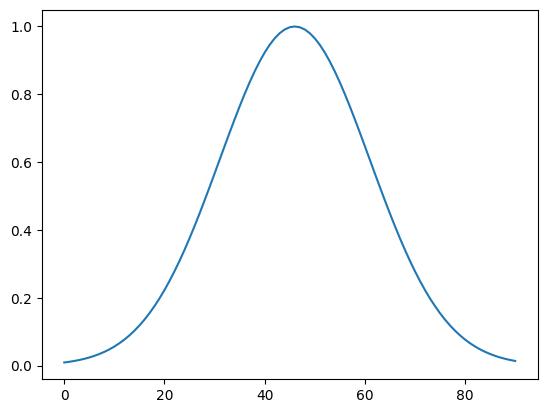

In [124]:
# plot the sim signal
plt.plot(data["sim_signal"][0])

In [125]:
data.keys()

dict_keys(['sim_vertex', 'n_layers', 'sim_layers', 'patch_size', 'err_level', 'sim_patch_size', 'n_temp_modes_ebb', 'n_spatial_modes', 'hann_windowing_ebb', 'snr', 'dipole_moment', 'sim_signal', 'win_size', 'woi', 'sfreq', 'thickness', 'time', 'ts_ebb', 'ts_ebb_layer', 'fs', 'fid_coords'])

In [126]:
n_layers = data["fs"].shape[1]

In [127]:
# get the relative free energy 
fs_matrix = data['fs']      # (n_rows, 11, 11)
relativeFs = np.array([
        fs_matrix[sim_idx, :] - fs_matrix[sim_idx, :].min()
        for sim_idx in range(fs_matrix.shape[0])
    ])

In [128]:
relativeFs.shape #(n_sim, n_layers)

(11, 11)

In [129]:
peaks = []
for sim_l in range(len(data["sim_layers"])):
    peak = np.argmax(relativeFs[sim_l, :])
    peaks.append(peak)
peaks = np.array(peaks)

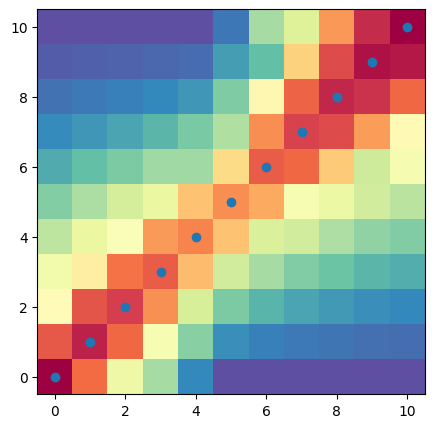

In [130]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
im0 = ax.imshow(relativeFs.T, cmap="Spectral_r", aspect="auto",
                    origin="lower", interpolation="nearest")
ax.scatter(list(range(n_layers)), peaks)

In [134]:
# get the ebb matrix
sfreq = data['sfreq']
thickness = data['thickness']
ebb_matrix = data['ts_ebb']      # (n_sim, n_layers)
csd_ebb = np.array([
        compute_csd(ebb_matrix[sim_idx, :], thickness, sfreq)
        for sim_idx in range(ebb_matrix.shape[0])
    ])

No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23

In [135]:
mx_csd = np.zeros((n_layers, csd_ebb.shape[1]))
peaks_csd = []
for sim_l in range(len(data["sim_layers"])):
    mx_csd[sim_l] = np.mean(csd_ebb[sim_l, :, 40:45], axis=1)
    peak_csd = np.argmax(mx_csd[sim_l])
    peaks_csd.append(peak_csd)
peaks_csd = np.array(peaks_csd)

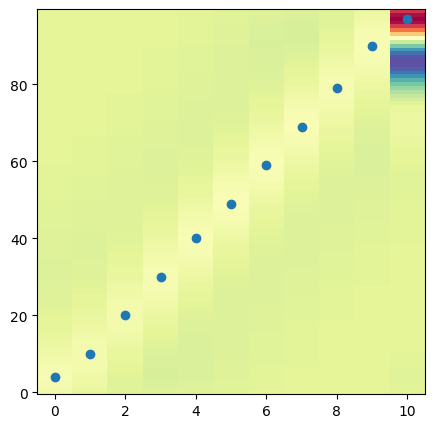

In [136]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
im0 = ax.imshow(mx_csd.T, cmap="Spectral_r", aspect="auto",
                    origin="lower", interpolation="nearest")
ax.scatter(list(range(n_layers)), peaks_csd)

In [138]:
# get the ebb_layer matrix
ebb_layer_matrix = data['ts_ebb_layer']      # (n_sim, n_layers)
csd_ebb_layer = np.array([
        compute_csd(ebb_layer_matrix[sim_idx, :], thickness, sfreq)
        for sim_idx in range(ebb_layer_matrix.shape[0])
    ])

No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01
No lambda given, using defaults
Cross validating R (all lambda) : 0.23

In [141]:
from scipy.signal import find_peaks
mx_csd_layer = np.zeros((n_layers, csd_ebb_layer.shape[1]))
peaks_csd_layer = []
for sim_l in range(len(data["sim_layers"])):
    mx_csd_layer[sim_l] = np.mean(csd_ebb_layer[sim_l, :, 40:45], axis=1)
    peak_csd = np.argmax(mx_csd_layer[sim_l])
    # peak_csd = find_peaks(mx_csd_layer[sim_l])[0]
    # if len(peak_csd) ==0:
    #     peak_csd = np.argmax(mx_csd_layer[sim_l])
    # else: 
    #     peak_csd = peak_csd[0]
    peaks_csd_layer.append(peak_csd)
peaks_csd_layer = np.array(peaks_csd_layer)

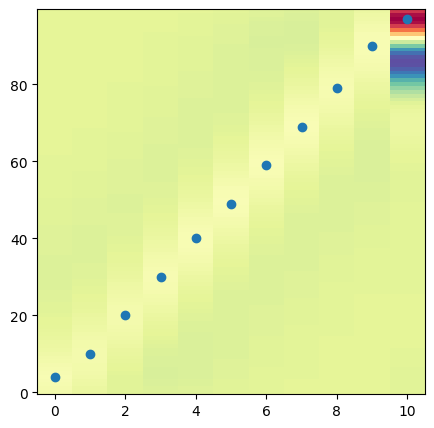

In [142]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
im0 = ax.imshow(mx_csd_layer.T, cmap="Spectral_r", aspect="auto",
                    origin="lower", interpolation="nearest")
ax.scatter(list(range(n_layers)), peaks_csd_layer)